Add Project Root to sys.path

In [129]:
import sys, os

# Add project root to Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)


Import Libraries    

In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from src.analysis_utils import compute_yearly_averages

Output Table

In [131]:
# Change the path to what suits your machine
df = pd.read_csv('../data/general_merchandise_stores_adjusted.csv', index_col = 0)
print(df)

        JAN    FEB    MAR    APR    MAY    JUN    JUL    AUG    SEP    OCT  \
YEAR                                                                         
2005  42404  43026  42732  43495  43317  44356  43910  44102  44282  45165   
2006  45505  45678  45515  45970  45664  45857  45750  46003  46465  46539   
2007  47824  47248  48024  47540  47821  47777  48260  48589  48260  48312   
2008  48796  48795  48786  49393  50181  50745  50491  49862  49349  49140   
2009  49136  49132  48722  48733  48916  48691  48734  48976  48959  49546   
2010  49771  50355  50094  50264  49799  49902  49824  50085  50146  50163   
2011  50726  51301  51474  51833  51627  52347  51992  51984  52422  52278   
2012  52999  53714  53550  53107  53078  53021  53147  53445  53328  53529   
2013  54074  54436  54028  54226  54395  54422  54513  54349  54790  54771   
2014  54546  55278  55364  55871  55826  55902  55993  56148  56141  56244   
2015  56552  56147  56365  56222  56637  56560  56926  56864  56

Create Plot

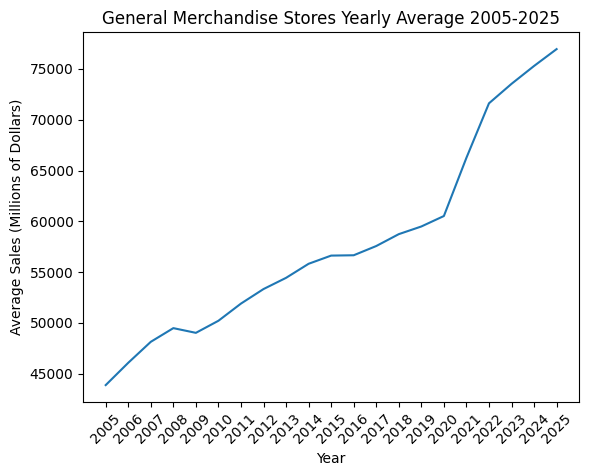

In [132]:
yearly_averages = compute_yearly_averages(df)

plt.plot(df.index, yearly_averages)
plt.title("General Merchandise Stores Yearly Average 2005-2025")
plt.xlabel("Year")
plt.ylabel("Average Sales (Millions of Dollars)")
plt.xticks(np.arange(2005, 2026, step=1))
plt.xticks(rotation = 45)

plt.show()

Unemployment Data

In [133]:
# Unemployment rate only from 2005 - 2025
unemployment_df = pd.read_csv('../data/civilian_unemployment_rate.csv', index_col = 0)

# Cleaning the data
columns_to_drop = ['Men_20plus', 'Women_20plus', 'Age_16_19', 'White', 'Black', 'Asian', 'Hispanic'] # Columns not needed

# Take from November only because that's when the census is taken for general merchandise
unemployment_df = unemployment_df[unemployment_df.index.str.startswith('Nov')]
unemployment_df = unemployment_df.drop(columns=columns_to_drop)
 
# Remove the month name from the column
unemployment_df.index = unemployment_df.index.str[4:]
unemployment_df.index = unemployment_df.index.astype(int) # Convert back to integer

print("Civilian Unemployment Data")
print(unemployment_df)

# Update Average Sales CSV to 2005-2025 only
df = df[df.index >= 2005]

yearly_averages = []

for year in df.index:
    average = df.loc[year].mean()
    yearly_averages.append(average)


# Checking if the data is clean
print("General Merchandise Data")
print(df)


Civilian Unemployment Data
       Total
Month       
2005     5.0
2006     4.5
2007     4.7
2008     6.8
2009     9.9
2010     9.8
2011     8.6
2012     7.7
2013     6.9
2014     5.8
2015     5.1
2016     4.7
2017     4.2
2018     3.8
2019     3.6
2020     6.7
2021     4.2
2022     3.6
2023     3.7
2024     4.2
2025     4.6
General Merchandise Data
        JAN    FEB    MAR    APR    MAY    JUN    JUL    AUG    SEP    OCT  \
YEAR                                                                         
2005  42404  43026  42732  43495  43317  44356  43910  44102  44282  45165   
2006  45505  45678  45515  45970  45664  45857  45750  46003  46465  46539   
2007  47824  47248  48024  47540  47821  47777  48260  48589  48260  48312   
2008  48796  48795  48786  49393  50181  50745  50491  49862  49349  49140   
2009  49136  49132  48722  48733  48916  48691  48734  48976  48959  49546   
2010  49771  50355  50094  50264  49799  49902  49824  50085  50146  50163   
2011  50726  51301  51474

General Merchandise vs Unemployment Rate Graph

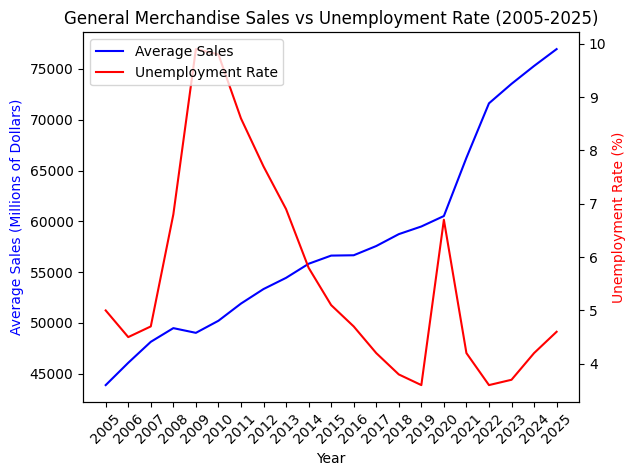

In [134]:
fig, ax1 = plt.subplots()

# Sales (left axis)
line1, = ax1.plot(df.index, yearly_averages, label="Average Sales", color="blue")
ax1.set_xlabel("Year")
ax1.set_ylabel("Average Sales (Millions of Dollars)", color="blue")
ax1.set_xticks(np.arange(2005, 2026, step=1))
plt.xticks(rotation=45)

# Unemployment (right axis)
ax2 = ax1.twinx()
line2, = ax2.plot(unemployment_df.index, unemployment_df['Total'], label="Unemployment Rate", color="red")
ax2.set_ylabel("Unemployment Rate (%)", color="red")

# Title
plt.title("General Merchandise Sales vs Unemployment Rate (2005-2025)")
plt.legend(handles=[line1, line2], loc="upper left")

plt.show()

General Merchandise vs Inflation Rate Graph

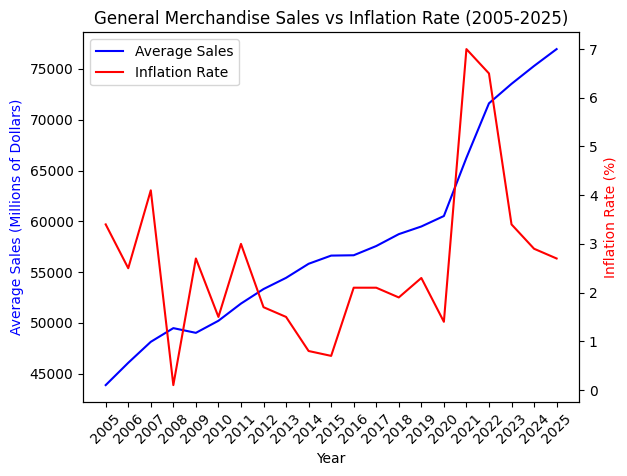

In [135]:
# Inflation rate data from 2005=2025
inflation_df = pd.read_csv('../data/inflation_rate.csv', index_col = 0)

fig, ax1 = plt.subplots()

# Sales (left axis)
line1, = ax1.plot(df.index, yearly_averages, label="Average Sales", color="blue")
ax1.set_xlabel("Year")
ax1.set_ylabel("Average Sales (Millions of Dollars)", color="blue")
ax1.set_xticks(np.arange(2005, 2026, step=1))
plt.xticks(rotation=45)

# Unemployment (right axis)
ax2 = ax1.twinx()
line2, = ax2.plot(inflation_df.index, inflation_df['Inflation Rate'], label="Inflation Rate", color="red")
ax2.set_ylabel("Inflation Rate (%)", color="red")

# Title
plt.title("General Merchandise Sales vs Inflation Rate (2005-2025)")
plt.legend(handles=[line1, line2], loc="upper left")

plt.show()

Finding the best model for forecasting future trends

C:\Users\Ajwad\AppData\Local\Temp\ipykernel_23972\484884976.py:21: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(X_train, y_train, order)


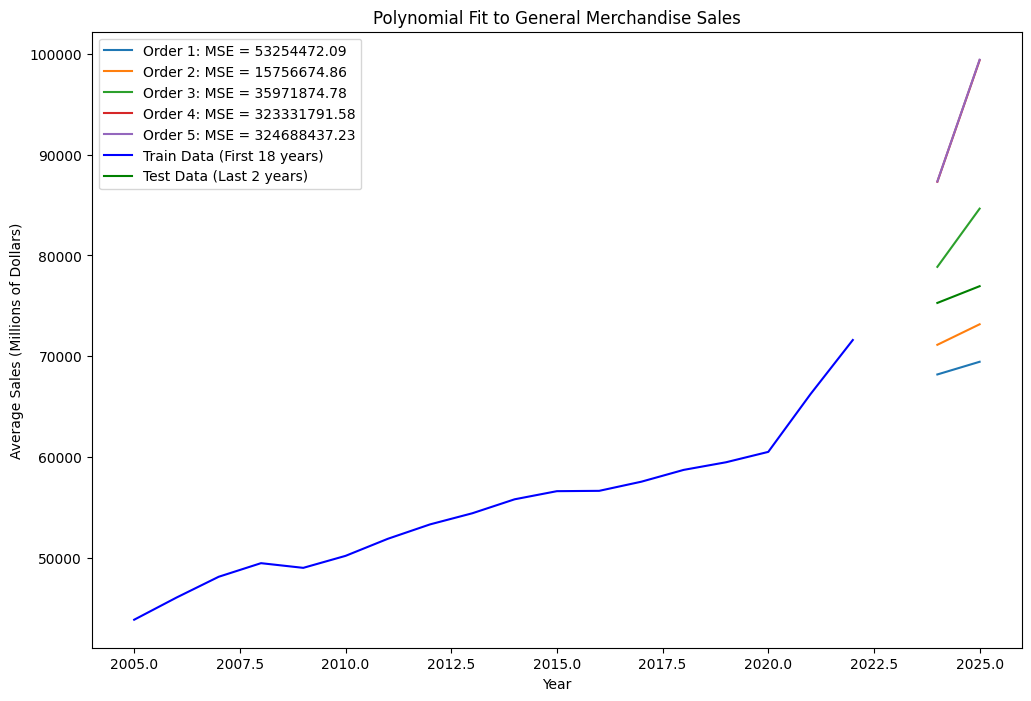

Polynomial Order 1: MSE = 53254472.09
Polynomial Order 2: MSE = 15756674.86
Polynomial Order 3: MSE = 35971874.78
Polynomial Order 4: MSE = 323331791.58
Polynomial Order 5: MSE = 324688437.23


In [136]:
# Split into train/test by year
split_year = df.index.min() + 18

train_df = df[df.index < split_year]
test_df = df[df.index >= split_year]

# Extract X and y
X_train = train_df.index.values[:18]
y_train = yearly_averages[:18]

X_test = test_df.index.values[-2:]
y_test = yearly_averages[-2:]

orders = [1, 2, 3, 4, 5]
mse_values = []

plt.figure(figsize=(12,8))

for order in orders:
    # Fit polynomial to the first 90 years
    coefficients = np.polyfit(X_train, y_train, order)
    polynomial = np.poly1d(coefficients)

    y_pred = polynomial(X_test)

    # Calculate mean squared error for the predictions
    mse = np.mean((y_test - y_pred)**2)
    mse_values.append(mse)

    # Plot the polynomial fit
    plt.plot(X_test, y_pred, label=f'Order {order}: MSE = {mse:.2f}')

# Plot the actual data
plt.plot(X_train, y_train, color='blue', label='Train Data (First 18 years)')
plt.plot(X_test, y_test, color='green', label='Test Data (Last 2 years)')

plt.xlabel('Year')
plt.ylabel('Average Sales (Millions of Dollars)')
plt.title('Polynomial Fit to General Merchandise Sales')
plt.legend()
plt.show()

# Print MSE values for comparison
for order, mse in zip(orders, mse_values):
    print(f"Polynomial Order {order}: MSE = {mse:.2f}")